In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
import pandas as pd
from tensorflow.keras.layers import Dense, Flatten, Input
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [ ]:
df = pd.read_csv(r"student-mat.csv", sep= ';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('G3', axis=1)
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(316, 32)
(79, 32)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

model = Sequential([
    Input(shape=(32,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
def r2_score(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=[r2_score]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 121.0199 - mae: 10.0259 - val_loss: 112.8529 - val_mae: 9.8740
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 109.5940 - mae: 9.5466 - val_loss: 101.5626 - val_mae: 9.3625
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 98.1922 - mae: 9.0562 - val_loss: 89.7087 - val_mae: 8.7861
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 85.8921 - mae: 8.4569 - val_loss: 76.9715 - val_mae: 8.1147
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 72.3217 - mae: 7.7642 - val_loss: 63.5960 - val_mae: 7.3328
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 58.8915 - mae: 6.9857 - val_loss: 49.9312 - val_mae: 6.4238
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 44.7027 - mae: 6.0374 - val_loss: 37.4936 - val_mae: 5.4769
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 32.8960 - mae: 5.0992 - val_loss: 26.6998 - val_mae: 4.4831
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 23

In [ ]:
loss, metric = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Metric:", metric)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.5595 - mae: 1.8547 
Loss: 6.55945348739624
Metric: 1.854683756828308


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.5883 - mae: 0.9478 - val_loss: 5.6913 - val_mae: 1.7724
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.5250 - mae: 0.9280 - val_loss: 5.6626 - val_mae: 1.7624
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.4783 - mae: 0.9126 - val_loss: 5.6161 - val_mae: 1.7546
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.4284 - mae: 0.8966 - val_loss: 5.5689 - val_mae: 1.7507
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.3707 - mae: 0.8779 - val_loss: 5.5209 - val_mae: 1.7357
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.3251 - mae: 0.8644 - val_loss: 5.4773 - val_mae: 1.7294
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.2847 - mae: 0.8492 - val_loss: 5.4223 - val_mae: 1.7119
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.2360 - mae: 0.8321 - val_loss: 5.4133 - val_mae: 1.7072
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1965 - mae: 0.8160 - 

In [ ]:
metrics=['mae']

In [ ]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.7999 - mae: 1.8315
Test Loss: 6.799893379211426
Test MAE: 1.8314740657806396


In [ ]:
loss, r2 = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test R2 Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.7999 - mae: 1.8315
Test Loss: 6.799893379211426
Test R2 Score: 1.8314740657806396


In [ ]:
predictions = model.predict(X_test)

print(predictions[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[ 7.9115286 ]
 [12.485048  ]
 [ 0.25243866]
 [ 9.96484   ]
 [11.763331  ]]


In [ ]:
print("First Prediction:", predictions[0][0])
print("Actual Value:", y_test.iloc[0])

First Prediction: 7.9115286
Actual Value: 10


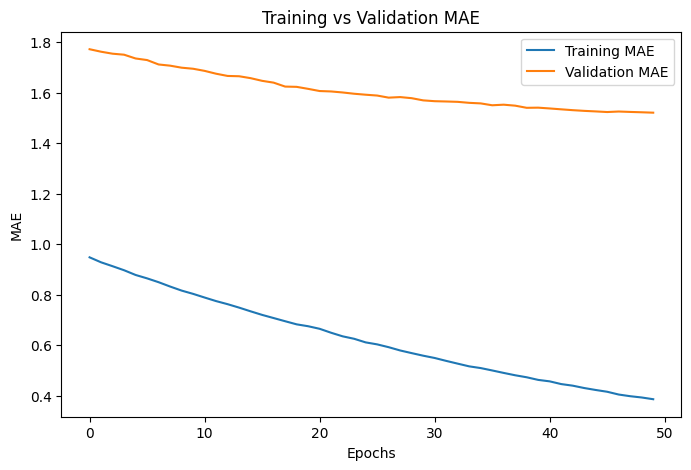

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

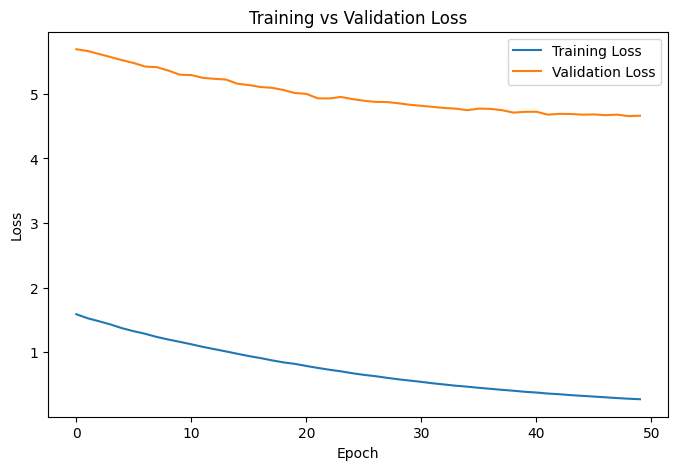

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()